# 02 · 확률에서 손실 만들기

**이번 질문:** MSE·BCE·cross-entropy는 어떤 관측을 잘 설명하려고 만든 식이며, 그 식을 어떻게 안정적인 코드로 옮길까요?

01번에서는 "예측 − 정답을 제곱해 평균낸다"는 손실을 **그냥 정했습니다.** 이번에는 그 식이 어디서 오는지 봅니다.
답은 확률입니다. "이 모델이라면 실제로 관측된 데이터가 나올 확률이 얼마인가"를 크게 만드는 것이 학습이고,
그 확률에 $-\log$를 붙인 것이 손실입니다. 관측이 실수(당도)냐, 예/아니오(7인가)냐, 열 가지 중 하나(어느 숫자인가)냐에 따라
MSE, BCE, softmax cross-entropy가 각각 나옵니다.

[00](00_math_to_numpy.ipynb)의 배열과 [01](01_gradients_and_learning.ipynb)의 미분을 사용합니다. 확률 기호는 이 노트북에서 다시 설명합니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 손실은 "관측이 나올 확률"에서 나옵니다. 손실 $=-\frac1N\sum\log(\text{관측의 확률})$. 확률을 크게 만드는 것과 손실을 작게 만드는 것은 같은 일입니다.
2. 관측의 종류가 손실을 정합니다. 실수 + 가우스 잡음 → MSE. 0/1 → BCE `logaddexp(0, z) - y*z`. K개 중 하나 → softmax CE `-log p[y]`.
3. 세 손실 모두 점수(logit)에 대한 기울기가 **"예측 확률 − 정답"**입니다. 코드로는 `(p - y) / N`.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/probability_plots.py)


In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)          # 현재 폴더부터 위로 올라가며
                    if (p / "src" / "utils" / "plotting.py").is_file())    # src/utils/plotting.py가 있는 첫 폴더를 고릅니다
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 검사기(6–8절), 데이터 로더, 이 노트북의 그림 함수(src/utils/probability_plots.py), 연습 검사 도우미
import numpy as np
from src.utils import setup_plots, plot_gradcheck
from src import check_function
from src.data.mnist import load_mnist, load_examples
from src.utils.probability_plots import (
    plot_pmf, plot_joint_table, plot_density_area, plot_likelihood_curves,
    plot_gaussian_observation, plot_bce_examples, plot_softmax_examples,
    plot_discrete, plot_density, plot_estimates, plot_likelihood,
    plot_loss_curves, plot_classifier,
)
from src.utils import run_check

# 3) 그림 설정. 배열 출력은 소수 5자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=5, suppress=True)
print("NumPy", np.__version__, "· 확률과 손실 준비 완료")

NumPy 2.4.6 · 확률과 손실 준비 완료


### 📎 이 노트북의 예시: 과일 상자, 당도 직선, MNIST

- **과일 상자.** 상자에서 과일 하나를 꺼내면 흠집 수 $A$가 0, 1, 2 중 하나이고, 붉은지($A$)와 단지($B$)도 기록합니다. 1–4절의 작은 확률 계산에 씁니다.
- **당도 직선.** 01번의 과일 데이터(붉기 $x$, 당도 $y$)입니다. 6절에서 "당도는 직선 주변에 가우스 잡음으로 흩어진다"는 가정에서 MSE를 얻습니다.
- **MNIST.** 00번의 고정 예시 10장입니다. 7절에서 "7인가"의 확률과 BCE를, 8절에서 열 숫자의 확률과 cross-entropy를 봅니다.
  점수는 학습 없이 00번의 템플릿(클래스 평균 − 전체 평균)으로 만듭니다. 아래 셀은 실행만 하고 넘어가도 됩니다.

> **코드**
>
> - `np.linspace(-2.0, 2.0, 40)[:, None]`: 같은 간격의 숫자 40개를 `[:, None]`으로 `(40, 1)` 열벡터로 세웁니다(01번과 같은 데이터).
> - `rng_fruit.normal(0.0, 0.15, size=...)`: 평균 0, 표준편차 0.15인 가우스 잡음. 시드를 고정했으므로 실행마다 같습니다.
> - `_`: 함수가 돌려준 값 중 쓰지 않는 것을 받아 버리는 관례상의 이름입니다.
> - `np.stack([mnist_X_all[mnist_y_all == k].mean(axis=0) - mean_all for k in range(10)], axis=1)`: k = 0…9마다 "정답이 k인 행만 골라 평균낸 뒤 전체 평균을 뺀 (784,)"를 만들고(컴프리헨션), 10개를 **열**로 나란히 쌓아 `(784, 10)`으로 만듭니다(00번 4절의 템플릿).

In [2]:
rng_fruit = np.random.default_rng(12)                                            # 시드를 고정한 난수 생성기
fruit_x = np.linspace(-2.0, 2.0, 40)[:, None]                                   # (40, 1): 과일 40개의 붉기
fruit_y = 2.0 * fruit_x + 0.7 + rng_fruit.normal(0.0, 0.15, size=fruit_x.shape)  # (40, 1): 당도 = 직선 2x + 0.7 + 잡음(표준편차 0.15)

mnist_examples, mnist_labels = load_examples(download=True)                      # (10, 28, 28) 예시 이미지 10장, (10,) 정답 숫자
mnist_Xe = mnist_examples.reshape(10, -1)                                        # (10, 784): 한 장을 한 행으로 펼침
mnist_X_all, mnist_y_all, _, _ = load_mnist()                                    # (60000, 784), (60000,). 시험용 두 값은 안 쓰므로 _ 로 버립니다
mean_all = mnist_X_all.mean(axis=0)                                              # (784,): 60,000장의 평균 이미지
templates = np.stack([mnist_X_all[mnist_y_all == k].mean(axis=0) - mean_all for k in range(10)], axis=1)  # (784, 10): 열 k = 숫자 k의 템플릿
print("과일", fruit_x.shape, "· MNIST 예시", mnist_Xe.shape, "· 템플릿", templates.shape)

과일 (40, 1) · MNIST 예시 (10, 784) · 템플릿 (784, 10)


## 🔑 1. 확률과 기댓값: 가능한 값에 가중치를 줍니다

**이 절에서 가져갈 것:** 기댓값은 "가능한 값 × 그 값이 나올 확률"을 모두 더한 것입니다. 코드로는 `np.sum(values * probabilities)`.

상자에서 과일 하나를 꺼냅니다. 흠집이 0개일 확률이 0.2, 1개일 확률이 0.5, 2개일 확률이 0.3이라고 합시다.
"흠집이 평균 몇 개일까"가 기댓값입니다.

> **용어**
>
> - **확률변수(random variable)** $A$: 결과에 따라 값이 달라지는 숫자. 여기서는 꺼낸 과일의 흠집 수, $A\in\{0,1,2\}$.
> - **확률(probability)** $P(A=a)$: 값 $a$가 나올 가능성. 음수가 아니고, 가능한 값 전체의 확률을 합하면 1.
> - **사건(event)**: 값들의 묶음. "흠집이 1개 이상"은 $A\ge1$이고, 확률은 $0.5+0.3=0.8$.
> - **기댓값(expectation)** $\mathbb E[A]$: 가능한 값의 확률 가중합. 실제로 나올 수 있는 값일 필요는 없습니다.

$$\mathbb E[f(A)]=\sum_i p_i f(a_i),\qquad \mathbb E[A]=0(0.2)+1(0.5)+2(0.3)=1.1.$$

📎 `values`, `probabilities`는 같은 `(3,)` 모양입니다. 값과 확률을 같은 인덱스로 짝지어 곱하고 합합니다.
`values >= 1`은 각 원소를 비교해 `[False, True, True]`라는 Boolean 배열을 만들고, `probabilities[values >= 1]`은 True인 위치의 확률만 꺼내는 마스크 인덱싱입니다.


In [3]:
values = np.array([0., 1., 2.])              # (3,): 가능한 흠집 수 a_i
probabilities = np.array([0.2, 0.5, 0.3])    # (3,): 각 값의 확률 p_i. 합 1
mean = np.sum(values * probabilities)         # 기댓값 Σ p_i a_i = 1.1
np.testing.assert_allclose(mean, 1.1)         # 검산: 손계산 0·0.2 + 1·0.5 + 2·0.3
print("P(A >= 1) =", probabilities[values >= 1].sum(), "· E[A] =", mean)

P(A >= 1) = 0.8 · E[A] = 1.1


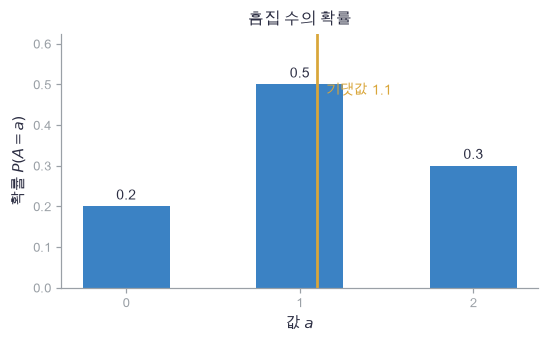

In [4]:
plot_pmf(values, probabilities, mean)

🔍 **확인** · 막대 높이가 각 값의 확률이고, 셋을 더하면 1입니다. 금색 선이 기댓값 1.1입니다. 확률이 큰 1 쪽으로 치우쳐 있고, 실제 흠집 수가 1.1개일 수는 없습니다.
분산 $\operatorname{Var}(A)=\mathbb E[(A-\mathbb E[A])^2]$도 새로운 평균 방식이 아니라, "기댓값에서 벗어난 정도의 제곱"에 같은 확률 가중합을 적용한 것입니다.
뒤의 Monte Carlo와 미니배치도 **무엇에 대해 평균내는지**를 먼저 정합니다.

In [5]:
def expectation(values, probabilities):
    """기댓값 E[f(A)] = Σ_i p_i f(a_i). values: (n,) 값 f(a_i), probabilities: (n,) 확률 → 숫자 하나."""
    values = np.asarray(values, dtype=float)                 # 리스트가 들어와도 실수 배열로
    probabilities = np.asarray(probabilities, dtype=float)
    assert values.ndim == 1, "values는 (n,) 1차원 배열이어야 합니다"
    assert values.shape == probabilities.shape, "값과 확률은 같은 개수여야 합니다"
    assert np.all(probabilities >= 0), "확률은 음수가 아니어야 합니다"
    assert np.isclose(probabilities.sum(), 1), "확률의 합은 1이어야 합니다"
    return np.sum(values * probabilities)

In [6]:
manual_sum = 0.0                                          # 같은 합을 반복문으로
for i in range(len(values)):
    manual_sum += probabilities[i] * values[i]
variance = expectation((values - mean) ** 2, probabilities)   # 분산 = "기댓값에서 벗어난 정도의 제곱"의 기댓값
np.testing.assert_allclose([expectation(values, probabilities), variance], [1.1, 0.49])   # 검산: E[A] = 1.1, Var = 0.2·1.21 + 0.5·0.01 + 0.3·0.81
np.testing.assert_allclose(mean, manual_sum)              # 검산: 배열 연산 = 반복문
print("E[A] =", expectation(values, probabilities), "· Var(A) =", variance)

E[A] = 1.1 · Var(A) = 0.49


### ✏️ 연습 1 · 분산도 같은 확률 가중합

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

기댓값 `mean_value`는 미리 계산해 두었습니다. "기댓값에서 벗어난 정도의 제곱" `(values - mean_value) ** 2`에 같은 확률 가중합을 적용한 분산 `variance` 한 줄을 채우세요. 1절의 `expectation`을 부르지 않고 `np.sum`으로 직접 쓰세요. 입력은 둘 다 `(n,)`이고 출력은 숫자 하나입니다. 1절 본문의 흠집 수 예제에서는 0.49가 나와야 합니다.

In [7]:
def exercise_variance(values, probabilities):
    """연습 1: 분산 Var(A) = Σ p_i (a_i − E[A])². values, probabilities: (n,) → 숫자 하나."""
    values = np.asarray(values, dtype=float)
    probabilities = np.asarray(probabilities, dtype=float)
    assert values.shape == probabilities.shape, "값과 확률은 같은 개수여야 합니다"
    assert np.isclose(probabilities.sum(), 1), "확률의 합은 1이어야 합니다"
    mean_value = np.sum(values * probabilities)      # 기댓값 E[A]. 1절의 한 줄
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 기댓값에서 벗어난 정도의 제곱 (values − mean_value)²에 같은 확률 가중합을 적용한 variance (숫자 하나)
    ### 힌트: 1절 🔍 셀의 분산 정의입니다. mean_value를 만든 줄과 같은 꼴이고, 값 자리에 제곱 편차가 들어갑니다.
    raise NotImplementedError
    return variance

In [8]:
def check_variance(candidate):
    """손계산 예제 둘로 후보 함수를 검사합니다. 통과하면 메시지를 출력합니다."""
    actual = candidate(np.array([0., 1., 2.]), np.array([0.2, 0.5, 0.3]))
    assert np.ndim(actual) == 0, f"분산은 숫자 하나여야 하는데 모양이 {np.shape(actual)}입니다"
    np.testing.assert_allclose(actual, 0.49)                                                    # 검산: 1절 본문. 0.2·1.21 + 0.5·0.01 + 0.3·0.81
    np.testing.assert_allclose(candidate(np.array([0., 2., 5.]), np.array([0.5, 0.25, 0.25])), 4.1875)   # 검산: E = 1.75, 0.5·1.75² + 0.25·0.25² + 0.25·3.25²
    print("분산: 손계산과 일치합니다.")

run_check(check_variance, exercise_variance, hint="variance = np.sum(probabilities * (values - mean_value) ** 2)")

☐ exercise_variance: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: variance = np.sum(probabilities * (values - mean_value) ** 2)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
variance = np.sum(probabilities * (values - mean_value) ** 2)
```

</details>

## 🔑 2. 결합·주변·조건부 확률: 합하는 축과 고정하는 축

**이 절에서 가져갈 것:** 두 변수의 확률표에서 한 축을 더하면 한 변수의 확률이 되고, 한 행을 그 행의 합으로 나누면 조건부 확률이 됩니다. 00번의 `axis`가 그대로 쓰입니다.

과일이 붉은지($A$: 1이면 붉음)와 단지($B$: 1이면 닮)를 함께 기록했더니 네 조합의 비율이 아래 표와 같았습니다. **행은 A, 열은 B**입니다.

$$P=\begin{bmatrix}0.3&0.2\\0.1&0.4\end{bmatrix}.$$

> **용어**
>
> - **결합확률(joint)** $P(A=a,B=b)$: 두 값이 **동시에** 나올 확률. 표의 칸 하나.
> - **주변확률(marginal)** $P(A=a)$: 다른 변수를 무시한 한 변수의 확률. 표에서 그 행을 모두 더한 것. `axis=1`을 합함.
> - **조건부확률(conditional)** $P(B=b\mid A=a)$: $A=a$로 **고정한 뒤** $B$의 확률. 그 행을 행의 합으로 나눈 것. 분모가 양수인 행에서만 정의.
> - **독립(independent)**: $P(B\mid A)$가 $A$에 따라 달라지지 않는 것. 이 표는 $P(B=1\mid A=1)=0.8$과 $P(B=1)=0.6$이 다르므로 독립이 아닙니다.


In [9]:
joint = np.array([[0.3, 0.2], [0.1, 0.4]])   # (2, 2): 결합확률표. 행 = A(붉음), 열 = B(닮)
p_a = joint.sum(axis=1)                 # (2,): A의 주변확률. 열 축을 더해 행마다 하나
p_b = joint.sum(axis=0)                 # (2,): B의 주변확률. 행 축을 더해 열마다 하나
b_given_a = joint / p_a[:, None]        # (2, 2): 각 행을 그 행의 확률로 나눔 → P(B | A). (2,)를 (2, 1)로 세워 행마다 나눔
np.testing.assert_allclose(joint.sum(), 1)                           # 검산: 네 칸의 합 = 1
np.testing.assert_allclose(b_given_a, [[0.6, 0.4], [0.2, 0.8]])      # 검산: 손계산 0.3/0.5, 0.2/0.5, 0.1/0.5, 0.4/0.5
np.testing.assert_allclose(b_given_a.sum(axis=1), 1)                 # 검산: 조건부확률은 행마다 합 1
a1_given_b1 = joint[1, 1] / p_b[1]      # P(A=1 | B=1): 열을 고정하고 그 열의 합으로 나눔
bayes = b_given_a[1, 1] * p_a[1] / p_b[1]   # 같은 값을 Bayes 식 P(B|A)P(A)/P(B)로
np.testing.assert_allclose([a1_given_b1, bayes], [2/3, 2/3])         # 검산: 0.4/0.6 = 2/3, 두 방향이 같음
print("P(A):", p_a, "P(B):", p_b)
print("행별 P(B | A):\n", b_given_a)
print("P(A=1 | B=1):", a1_given_b1)

P(A): [0.5 0.5] P(B): [0.4 0.6]
행별 P(B | A):
 [[0.6 0.4]
 [0.2 0.8]]
P(A=1 | B=1): 0.6666666666666666


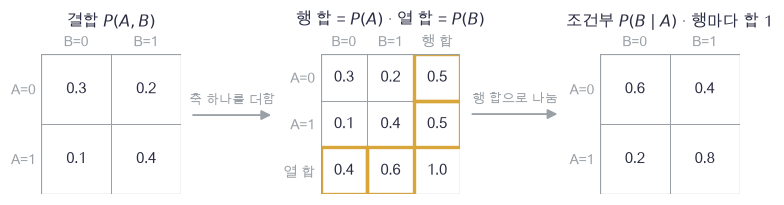

In [10]:
plot_joint_table(joint, p_a, p_b, b_given_a, ["A=0", "A=1"], ["B=0", "B=1"])

🔍 **확인** · A=1은 붉음, B=1은 닮입니다. 가운데 표의 금색 칸이 주변확률입니다. 행을 더하면 $P(A)$, 열을 더하면 $P(B)$이고, 어느 쪽으로 더해도 총합은 1입니다.
오른쪽은 각 행을 그 행의 합으로 나눈 조건부확률이라 행마다 합이 1입니다. 붉은 과일이 달 확률 0.8은 전체가 달 확률 0.6보다 큽니다.

📎 같은 결합확률을 두 방향으로 나누면 Bayes 식 $P(A\mid B)=P(B\mid A)P(A)/P(B)$가 나옵니다.
분류기는 앞으로 $P_\theta(Y\mid X)$를 계산합니다. 입력 $X$를 고정했을 때 라벨 $Y$에 배정할 확률을 파라미터 $\theta$로 정합니다.

### ✏️ 연습 2 · 열을 고정하면 P(A | B)

본문은 행(A)을 고정해 `P(B | A)`를 만들었습니다. 이번에는 열(B)을 고정합니다. 결합확률표 `joint` `(I, J)`에서 행 축을 더한 B의 주변확률 `p_b` `(J,)`와, 각 열을 그 열의 주변확률로 나눈 `a_given_b` `(I, J)` 두 줄을 채우세요. 본문의 `P(A=1 | B=1) = 2/3`이 표의 오른쪽 아래 칸에 나와야 합니다.

In [11]:
def exercise_conditional_on_b(joint):
    """연습 2: 열을 고정한 조건부확률 P(A | B). joint: (I, J) 결합확률표(행 = A, 열 = B) → (p_b: (J,), a_given_b: (I, J))."""
    assert joint.ndim == 2, "결합확률표는 (I, J) 2차원 배열이어야 합니다"
    assert np.isclose(joint.sum(), 1), "결합확률표의 모든 칸을 더하면 1이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 행 축을 더해 열마다 하나 남긴 B의 주변확률 p_b (J,)와, 각 열을 그 열의 주변확률로 나눈 a_given_b (I, J)
    ### 힌트: 2절 계산 셀의 p_b 줄과, b_given_a 줄에서 축만 바꾼 것입니다. (J,)로 (I, J)를 나누면 열마다 나뉘므로 [:, None]이 필요 없습니다.
    raise NotImplementedError
    return p_b, a_given_b

In [12]:
def check_conditional_on_b(candidate):
    """2절의 (2, 2) 표와 정사각형이 아닌 (3, 2) 표로 검사합니다. 통과하면 메시지를 출력합니다."""
    example_joint = np.array([[0.3, 0.2], [0.1, 0.4]])                       # (2, 2): 2절 본문의 표. 행 = A, 열 = B
    p_b, a_given_b = candidate(example_joint)
    assert p_b.shape == (2,), f"B의 주변확률은 (J,) = (2,)여야 하는데 {p_b.shape}입니다"
    assert a_given_b.shape == (2, 2), f"P(A | B)는 표와 같은 (2, 2)여야 하는데 {a_given_b.shape}입니다"
    np.testing.assert_allclose(p_b, [0.4, 0.6])                              # 검산: 열마다 더함 [0.3+0.1, 0.2+0.4]
    np.testing.assert_allclose(a_given_b, [[0.75, 1/3], [0.25, 2/3]])       # 검산: 열마다 나눔 0.3/0.4, 0.2/0.6, 0.1/0.4, 0.4/0.6
    np.testing.assert_allclose(a_given_b.sum(axis=0), 1)                     # 검산: 열을 고정했으니 열마다 합 1
    tall_joint = np.array([[0.1, 0.2], [0.3, 0.1], [0.2, 0.1]])             # (3, 2): A가 세 값이면 축을 잘못 고른 답은 모양부터 다름
    tall_p_b, tall_a_given_b = candidate(tall_joint)
    np.testing.assert_allclose(tall_p_b, [0.6, 0.4])                         # 검산: [0.1+0.3+0.2, 0.2+0.1+0.1]
    np.testing.assert_allclose(tall_a_given_b, [[1/6, 0.5], [0.5, 0.25], [1/3, 0.25]])   # 검산: 0.1/0.6, 0.2/0.4, 0.3/0.6, 0.1/0.4, 0.2/0.6, 0.1/0.4
    print("P(A | B): 손계산과 일치합니다.")

run_check(check_conditional_on_b, exercise_conditional_on_b, hint="p_b = joint.sum(axis=0), a_given_b = joint / p_b")

☐ exercise_conditional_on_b: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: p_b = joint.sum(axis=0), a_given_b = joint / p_b


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
p_b = joint.sum(axis=0)
a_given_b = joint / p_b
```

</details>

## 🔑 3. 연속값: 확률밀도는 넓이로 확률이 됩니다

**이 절에서 가져갈 것:** 연속 값에서는 "정확히 그 값"의 확률이 0이라, 대신 **밀도**를 씁니다. 구간의 확률은 밀도 곡선 아래 넓이입니다.

흠집 수는 0, 1, 2처럼 셀 수 있었지만 과일의 무게는 0.1234… kg처럼 어떤 실수든 될 수 있습니다.
무게 $U$가 0에서 0.25 kg 사이에서 고르게 나온다고 하면, "정확히 0.1 kg"일 확률은 0입니다. 그래서 확률 대신 밀도를 씁니다.

> **용어**
>
> - **확률밀도(probability density)** $p(u)$: 값 근처의 "확률의 진하기". 높이는 1보다 커도 되지만, 곡선 아래 전체 넓이는 1이어야 합니다.
> - **적분** $\int_a^b p(u)\,du$: $a$부터 $b$까지 곡선 아래 넓이. 작은 막대의 `높이 × 폭`을 모두 더한 것으로 근사합니다.

$$P(a\le U\le b)=\int_a^b p(u)\,du,\qquad P(0.05\le U\le0.15)=4\times(0.15-0.05)=0.4.$$

📎 아래의 `(조건1) & (조건2)`는 원소별로 두 조건이 모두 참인지 검사합니다.
`np.where(조건, 참일 때 값, 거짓일 때 값)`는 각 위치에서 조건에 따라 값을 선택합니다. `p(0.1)=4`는 그 한 점의 확률이 아니라 밀도입니다.

> **코드**
>
> - `edges[:-1]`, `edges[1:]`: 마지막 하나를 뺀 것과 첫 하나를 뺀 것. 둘을 더해 2로 나누면 이웃한 경계의 중점 1,000개가 됩니다.
> - `np.diff(edges)`: 이웃한 원소의 차이. 여기서는 막대 하나의 폭입니다.

In [13]:
edges = np.linspace(0, 0.25, 1001)        # (1001,): 구간 경계
midpoints = (edges[:-1] + edges[1:]) / 2  # (1000,): 막대 중심
widths = np.diff(edges)                  # (1000,): 각 막대 폭 0.00025
density = np.where((0 <= midpoints) & (midpoints <= 0.25), 1 / 0.25, 0.0)   # (1000,): 구간 안에서 밀도 4, 밖에서 0
interval = (midpoints >= 0.05) & (midpoints <= 0.15)                        # (1000,): 넓이를 잴 구간에 든 막대만 True
total_area = np.sum(density * widths)                                       # 높이 × 폭의 합 = 전체 넓이
interval_probability = np.sum(density[interval] * widths[interval])          # 구간 안 막대만 더한 넓이
np.testing.assert_allclose([total_area, interval_probability], [1, 0.4])     # 검산: 전체 넓이 1, 구간 넓이 4 × 0.1
print("밀도 높이", density[0], "· 전체 넓이", total_area, "· 구간 확률", interval_probability)

밀도 높이 4.0 · 전체 넓이 1.0 · 구간 확률 0.39999999999999997


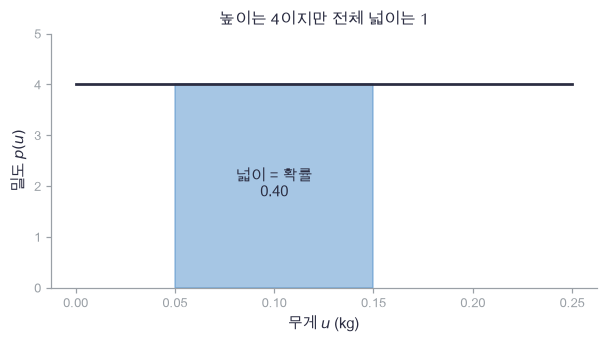

In [14]:
plot_density_area(midpoints, density, interval, interval_probability, total_area)

🔍 **확인** · 밀도의 높이 4는 확률이 아닙니다. 폭 0.1인 구간의 넓이 $4\times0.1=0.4$가 확률입니다.
앞의 확률표에서는 값을 **합해서** 1이 되었고, 밀도에서는 **넓이를 합해서** 1이 됩니다. 6절에서 당도를 가우스 밀도로 설명할 때 이 차이가 다시 필요합니다.

In [15]:
def uniform_density(x, low=0.0, high=0.25):
    """균등분포의 밀도: low ≤ x ≤ high이면 1/(high − low), 밖에서는 0. x: 숫자 또는 배열 → 같은 모양."""
    x = np.asarray(x, dtype=float)
    assert high > low, "구간의 끝 high가 시작 low보다 커야 합니다"
    return np.where((low <= x) & (x <= high), 1 / (high - low), 0.0)

In [16]:
np.testing.assert_allclose(uniform_density(midpoints), density)          # 검산: 위 그림의 밀도와 같은 함수
np.testing.assert_allclose(uniform_density(np.array([-0.1, 0.1, 0.3])), [0., 4., 0.])   # 검산: 구간 밖 0, 안 4
print("구간 밖은 0, 안은", uniform_density(0.1))

구간 밖은 0, 안은 4.0


### ✏️ 연습 3 · 구간의 확률은 넓이

막대의 중심 `midpoints`, 폭 `widths`, 그 자리의 밀도 `density`는 미리 만들어 두었습니다. 중심이 `a` 이상 `b` 이하인 막대만 고르는 Boolean 배열 `inside`와, 그 막대들의 `높이 × 폭`을 더한 `probability` 두 줄을 채우세요. 본문의 구간 `[0.05, 0.15]`에서는 0.4, 폭이 0인 구간에서는 0이 나와야 합니다.

In [17]:
def exercise_interval_probability(a, b, n=1000):
    """연습 3: 균등분포 U(0, 0.25)에서 구간 [a, b]의 확률을 막대 넓이의 합으로. a, b: 숫자, n: 막대 수 → 숫자 하나."""
    assert a <= b, "구간의 시작 a가 끝 b보다 크면 안 됩니다"
    edges = np.linspace(0, 0.25, n + 1)             # (n+1,): 구간 경계
    midpoints = (edges[:-1] + edges[1:]) / 2        # (n,): 막대 중심
    widths = np.diff(edges)                         # (n,): 막대 폭
    density = uniform_density(midpoints)            # (n,): 막대 중심의 밀도. 3절 함수
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 중심이 a 이상 b 이하인 막대만 True인 inside (n,)와, 그 막대들의 높이 × 폭을 모두 더한 probability (숫자 하나)
    ### 힌트: 3절 계산 셀의 interval과 interval_probability 두 줄입니다. 두 조건은 &로 잇고, Boolean 배열로 density와 widths를 골라냅니다.
    raise NotImplementedError
    return probability

In [18]:
def check_interval_probability(candidate):
    """3절 본문의 구간과 전체 구간, 분포 밖으로 나간 구간으로 검사합니다. 통과하면 메시지를 출력합니다."""
    np.testing.assert_allclose(candidate(0.05, 0.15), 0.4)     # 검산: 3절 본문. 높이 4 × 폭 0.1
    np.testing.assert_allclose(candidate(0.0, 0.25), 1.0)      # 검산: 전체 넓이 1
    np.testing.assert_allclose(candidate(0.2, 0.3), 0.2)       # 검산: 0.25 밖은 밀도 0이라 4 × 0.05만 남음
    np.testing.assert_allclose(candidate(0.1, 0.1), 0.0)       # 검산: 폭 0인 "정확히 그 값"의 확률은 0
    print("구간의 확률: 손계산과 일치합니다.")

run_check(check_interval_probability, exercise_interval_probability, hint="inside = (midpoints >= a) & (midpoints <= b); probability = np.sum(density[inside] * widths[inside])")

☐ exercise_interval_probability: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: inside = (midpoints >= a) & (midpoints <= b); probability = np.sum(density[inside] * widths[inside])


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
inside = (midpoints >= a) & (midpoints <= b)
probability = np.sum(density[inside] * widths[inside])
```

</details>

## 🔍 4. Monte Carlo: 표본 평균으로 기댓값을 추정합니다

> **용어**
>
> - **표본(sample)**: 분포에서 실제로 뽑힌 값 하나. 상자에서 과일을 꺼내 흠집 수를 세는 것.
> - **Monte Carlo 추정**: 모든 값에 확률을 곱하는 대신, 뽑힌 표본들의 **평균**으로 기댓값을 근사하는 것.
> - **표준오차(standard error)**: 표본 평균이 표본마다 흔들리는 정도. 표본 수 $M$이 커지면 $1/\sqrt M$로 줄어듭니다.

$$\mathbb E[f(A)]\approx\frac1M\sum_{m=1}^M f(a^{(m)}).$$

왼쪽은 모든 가능한 값에 확률을 곱하는 계산이고, 오른쪽은 실제로 뽑힌 값들의 평균입니다.
`rng.choice(..., p=...)`는 지정한 확률로 값을 뽑습니다. `seed`는 이 예제를 다시 실행할 때 같은 표본을 만들기 위한 설정입니다.
한 번의 추정 오차가 표본 수에 따라 계속 감소한다고 보장하지는 않습니다.

> **코드**
>
> - `np.cumsum(samples)`: 앞에서부터의 누적 합 `[s0, s0+s1, s0+s1+s2, …]`. `np.arange(1, M+1)` = `[1, 2, …, M]`으로 나누면 "표본 m개까지의 평균"이 한 번에 나옵니다.

In [19]:
# 쓰는 것: values, probabilities, mean, variance (1절)
rng = np.random.default_rng(202)
samples = rng.choice(values, size=5000, p=probabilities)   # (5000,): 확률 p로 값 5,000개를 뽑음 (복원추출)
counts = np.arange(1, len(samples) + 1)                    # (5000,): 1, 2, …, 5000
running_mean = np.cumsum(samples) / counts                 # (5000,): 앞에서 m개까지의 표본 평균
sample_mean = samples.mean()                               # 5,000개 전체의 표본 평균
standard_error = np.sqrt(variance / len(samples))          # 표본 평균의 표준편차 = √(Var/M). 1절에서 손계산한 분산을 씀
np.testing.assert_allclose(running_mean[-1], sample_mean)  # 검산: 누적 평균의 마지막 값 = 전체 평균
print(f"정확한 E[A]={mean:.4f}, 이번 표본 평균={sample_mean:.4f}, 표준오차={standard_error:.4f}")

정확한 E[A]=1.1000, 이번 표본 평균=1.1046, 표준오차=0.0099


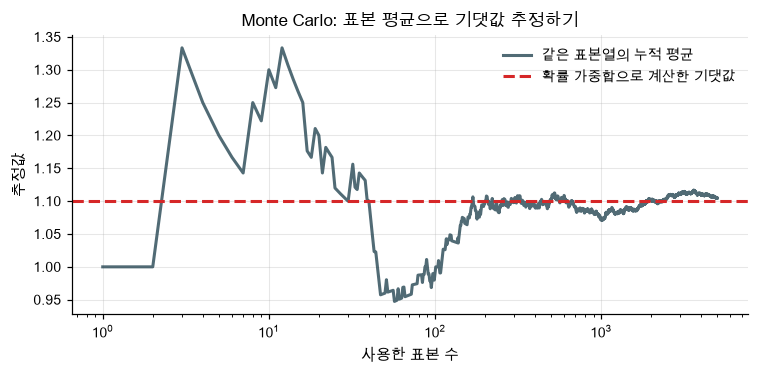

In [20]:
plot_estimates(counts, running_mean, mean)

🔍 **확인** · 표본이 쌓일수록 누적 평균이 확률 가중합으로 구한 1.1에 가까워집니다.
학습 데이터의 평균 손실도 같은 형태입니다. 표본 손실의 평균으로 데이터가 나오는 분포의 기대 손실을 추정합니다.
유한한 학습 데이터에서 잘 맞는 것과 새 데이터에서도 잘 맞는 것은 구분해야 합니다.

## 🔑 5. 관측에서 목적함수로: 우도와 음의 로그우도

**이 절에서 가져갈 것:** 관측을 고정하고 파라미터 후보를 바꿔 가며 "이 후보라면 이 관측이 나올 확률"을 계산한 것이 우도입니다. 우도가 가장 큰 후보를 고르는 것이 학습이고, $-\log$를 붙여 평균낸 것이 손실입니다.

### 📎 먼저, 곱·지수·로그의 기호를 연결합니다

> **용어**
>
> - $\prod$ **(곱 기호)**: $\prod_{n=1}^N a_n=a_1a_2\cdots a_N$. 합 기호 $\sum$의 곱 버전.
> - **지수함수** $\exp(u)=e^u$: 밑이 $e\approx2.71828$인 거듭제곱. 항상 양수.
> - **자연로그** $\log x$: "$e$를 몇 제곱하면 $x$가 되는가". $e^{\log x}=x$이고 입력은 양수여야 합니다.

$e^{u+v}=e^u e^v$이므로 $\log(ab)=\log a+\log b$입니다. **곱을 합으로 바꿀 수 있습니다.** 또한 $\log(a^r)=r\log a$입니다.
이 노트북에 필요한 두 미분 규칙은 다음과 같습니다.

$$\frac{d}{du}e^u=e^u,\qquad \frac{d}{dx}\log x=\frac1x.$$

코드의 `np.exp`·`np.log`가 이 두 함수이며, `np.log1p(t)`는 작은 t에서도 $\log(1+t)$를 정확히 계산하는 함수입니다.


In [21]:
np.testing.assert_allclose(np.exp(np.log(3.0)), 3.0)                       # 검산: e^(log 3) = 3
np.testing.assert_allclose(np.log(2.0 * 3.0), np.log(2.0) + np.log(3.0))    # 검산: log(ab) = log a + log b
eps = 1e-6
x = 2.0
log_derivative = (np.log(x + eps) - np.log(x - eps)) / (2 * eps)   # 중심차분 (01번 3절)
exp_derivative = (np.exp(x + eps) - np.exp(x - eps)) / (2 * eps)
np.testing.assert_allclose(log_derivative, 1/x, rtol=1e-8)          # 검산: (log x)' = 1/x
np.testing.assert_allclose(exp_derivative, np.exp(x), rtol=1e-8)    # 검산: (e^x)' = e^x
print("log의 변화율", log_derivative, "· exp의 변화율", exp_derivative)

log의 변화율 0.5000000000143778 · exp의 변화율 7.3890560989831044


### 🔑 고정한 관측에 파라미터 후보를 대입합니다

상자에서 과일 4개를 꺼내 맛보니 달다, 달다, 안 달다, 달다(`1, 1, 0, 1`)였습니다. "이 상자의 과일이 달 확률" $\theta$를 정하려고 합니다.
관측은 고정하고 후보 $\theta$를 바꿔 가며, 그 후보에서 이 네 관측이 나올 확률을 계산합니다. 네 관측이 서로 독립이라면 곱입니다.

> **용어**
>
> - **우도(likelihood)** $L(\theta)$: 관측을 고정했을 때 파라미터 후보의 점수. $P_\theta(Y)$는 $\theta$를 고정하고 $Y$의 분포를 본 것이고, $L(\theta)$는 같은 식을 $\theta$의 함수로 본 것. $\theta$에 대해 합이 1일 필요는 없습니다.
> - **최대우도(maximum likelihood)**: 우도가 가장 큰 후보를 고르는 원칙.
> - **음의 로그우도(negative log-likelihood, NLL)**: $-\log L$. 곱이 합이 되고, "크게"가 "작게"로 바뀌어 손실로 쓸 수 있습니다.

$$L(\theta)=\prod_{n=1}^N \theta^{y_n}(1-\theta)^{1-y_n}=\theta^3(1-\theta).$$

양수에서 로그는 단조증가하므로 우도 최대화와 로그우도 최대화는 같은 후보를 선택합니다. 곱을 로그의 합으로 바꾸고 음수를 붙여 **최소화할 손실**로 씁니다.

$$J(\theta)=-\frac1N\log L(\theta)=-\frac1N\sum_n[y_n\log\theta+(1-y_n)\log(1-\theta)].$$

이 동전 문제에서는 $J'(\theta)=-\bar y/\theta+(1-\bar y)/(1-\theta)=0$을 풀면 $\theta=\bar y=0.75$입니다. 관측된 비율이 최선의 후보입니다.

> **코드**
>
> - `t ** fruit_taste * (1 - t) ** (1 - fruit_taste)`: 관측마다 y = 1이면 t, y = 0이면 1 − t가 되는 배열. 수식의 $\theta^{y_n}(1-\theta)^{1-y_n}$입니다.
> - `np.prod(…)`: 배열의 모든 원소를 곱합니다. 수식의 $\prod$.
> - `[식 for t in theta_grid]`(컴프리헨션): 후보 t마다 식을 계산해 목록으로 모읍니다. `np.array`로 감싸 배열로 만듭니다.
> - `np.argmax(a)`, `np.argmin(a)`: 가장 큰(작은) 값이 몇 번째인지.

In [22]:
fruit_taste = np.array([1., 1., 0., 1.])              # (4,): 관측. 달다=1
theta_grid = np.linspace(0.01, 0.99, 99)              # (99,): 후보 θ = 0.01, 0.02, …, 0.99
likelihoods = np.array([np.prod(t ** fruit_taste * (1 - t) ** (1 - fruit_taste)) for t in theta_grid])   # (99,): 후보마다 우도 L(θ) = Π θ^y (1−θ)^(1−y)
nlls = -np.array([np.mean(fruit_taste * np.log(t) + (1 - fruit_taste) * np.log(1 - t)) for t in theta_grid])   # (99,): 후보마다 NLL J(θ)
best = theta_grid[np.argmax(likelihoods)]             # 우도가 가장 큰 후보
np.testing.assert_allclose([best, theta_grid[np.argmin(nlls)]], [0.75, 0.75])   # 검산: 우도 최대 = NLL 최소 = 관측 비율 3/4
print("최대 우도 후보", best, "· 그때 우도", likelihoods.max().round(4), "· NLL", nlls.min().round(4))

최대 우도 후보 0.75 · 그때 우도 0.1055 · NLL 0.5623


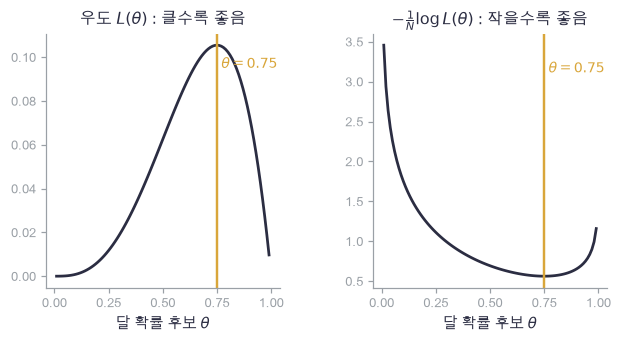

In [23]:
plot_likelihood_curves(theta_grid, likelihoods, nlls, best)

🔍 **확인** · 왼쪽 우도가 가장 높은 곳과 오른쪽 NLL이 가장 낮은 곳이 같은 $\theta=0.75$입니다. 관측된 비율 3/4입니다.
$-\log$는 "크게"를 "작게"로 뒤집기만 하고 최선의 후보를 바꾸지 않습니다. 뒤의 모든 손실은 이 NLL의 특수한 경우입니다.

> **코드** · `(targets == 0) | (targets == 1)`: 원소별 "또는". 값이 0이거나 1인 자리만 True입니다. `&`는 "그리고"입니다.

In [24]:
def bernoulli_nll(probability, targets):
    """Bernoulli 관측의 음의 로그우도 평균: J = −(1/N) Σ [y log p + (1 − y) log(1 − p)].
    probability: 숫자 또는 (N,) 확률 p, targets: (N,) 0/1 관측 → 숫자 하나."""
    probability = np.asarray(probability, dtype=float)
    targets = np.asarray(targets, dtype=float)
    assert np.all((probability > 0) & (probability < 1)), "확률은 0과 1 사이(양 끝 제외)여야 log가 정의됩니다"
    assert np.all((targets == 0) | (targets == 1)), "관측은 0 또는 1이어야 합니다"
    return -np.mean(targets * np.log(probability)
                    + (1 - targets) * np.log1p(-probability))     # log1p(−p) = log(1 − p)를 작은 p에서도 정확히

In [25]:
np.testing.assert_allclose([bernoulli_nll(t, fruit_taste) for t in theta_grid], nlls)   # 검산: 위 그림의 NLL과 같은 함수
np.testing.assert_allclose(bernoulli_nll(0.5, fruit_taste), np.log(2))                   # 검산: θ = 0.5면 관측마다 −log 0.5 = log 2
print("log(곱)와 log의 합:", np.log(np.prod(0.75 ** fruit_taste * 0.25 ** (1 - fruit_taste))),
      -len(fruit_taste) * bernoulli_nll(0.75, fruit_taste))       # 우도의 log = −N × (평균 NLL)

log(곱)와 log의 합: -2.2493405784752336 -2.249340578475233


📎 **참고** · 곱하는 수가 많으면 부동소수점에서 우도가 0으로 작아질 수 있습니다. 로그의 합은 그렇지 않습니다. 다음 셀에서 경고 없이 그 차이를 직접 확인합니다.

> **코드**
>
> - `np.full(2000, 0.5)`: 0.5로 채운 길이 2,000의 배열.
> - `with np.errstate(under="ignore"):`: 이 블록 안에서만 "너무 작아 0이 됨"(underflow) 경고를 끕니다. 일부러 그 현상을 보려는 것이기 때문입니다.

In [26]:
with np.errstate(under="ignore"):
    tiny_likelihood = np.prod(np.full(2000, 0.5))       # 0.5를 2,000번 곱함 = 2^−2000: 부동소수점 최솟값보다 작아 0
log_likelihood = np.log(0.5) * 2000                     # 같은 값의 로그: −1386. 문제없이 표현됨
assert tiny_likelihood == 0, "2,000개 확률의 곱은 부동소수점에서 0이 되어야 합니다"
assert np.isfinite(log_likelihood), "로그의 합은 유한해야 합니다"
print("2000개 확률의 곱:", tiny_likelihood, "· 로그의 합:", log_likelihood)

2000개 확률의 곱: 0.0 · 로그의 합: -1386.2943611198905


### ✏️ 연습 5 · 후보 하나의 우도와 NLL

본문은 후보 99개를 컴프리헨션으로 한꺼번에 계산했습니다. 이번에는 후보 `theta` 하나에 대해 관측 `targets` `(N,)`이 나올 확률 `likelihood`와, 그 로그에 음수를 붙여 `N`으로 나눈 `nll` 두 줄을 채우세요. 관측 `1, 1, 0, 1`에 `theta = 0.75`를 넣으면 우도 $0.75^3\times0.25 = 27/256$이 나와야 합니다. 관측이 4개라 곱이 그대로 표현되지만, 관측이 많으면 위 📎처럼 이 곱은 0이 되므로 실제 학습에서는 로그의 합으로 계산합니다. 그래서 5절의 `bernoulli_nll`은 곱을 만들지 않고 `np.log1p`로 씁니다. 검사는 두 계산이 같은 값인지도 봅니다.

In [27]:
def exercise_likelihood(theta, targets):
    """연습 5: 후보 θ 하나의 우도 L(θ)와 평균 NLL J(θ). theta: 0과 1 사이 숫자, targets: (N,) 0/1 관측 → (likelihood: 숫자, nll: 숫자)."""
    targets = np.asarray(targets, dtype=float)
    assert 0 < theta < 1, "후보 θ는 0과 1 사이(양 끝 제외)여야 합니다"
    assert np.all((targets == 0) | (targets == 1)), "관측은 0 또는 1이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 관측마다 y = 1이면 θ, y = 0이면 1 − θ가 되는 값을 모두 곱한 likelihood와, 그 로그에 음수를 붙여 관측 수 N으로 나눈 nll
    ### 힌트: 5절 계산 셀의 likelihoods에서 후보 하나분(np.prod)입니다. nll은 수식 J(θ) = −(1/N) log L(θ) 그대로입니다.
    raise NotImplementedError
    return likelihood, nll

In [28]:
def check_likelihood(candidate):
    """5절 본문의 관측 1, 1, 0, 1로 후보 둘을 검사하고, 다른 관측 하나로 더 확인합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: bernoulli_nll (5절)
    example_targets = np.array([1., 1., 0., 1.])                        # (4,): 5절 본문의 관측
    likelihood, nll = candidate(0.75, example_targets)
    np.testing.assert_allclose(likelihood, 27 / 256)                    # 검산: θ³(1 − θ) = 0.75³ × 0.25
    np.testing.assert_allclose(nll, -np.log(27 / 256) / 4)              # 검산: −log L / N
    np.testing.assert_allclose(nll, bernoulli_nll(0.75, example_targets))   # 검산: 곱으로 구한 NLL = 로그 합으로 구한 5절 NLL (작은 N에서만 되는 비교)
    half_likelihood, half_nll = candidate(0.5, example_targets)
    np.testing.assert_allclose([half_likelihood, half_nll], [1 / 16, np.log(2)])   # 검산: 0.5⁴ = 1/16, 관측마다 −log 0.5
    other_likelihood, _ = candidate(0.2, np.array([0., 0., 1.]))
    np.testing.assert_allclose(other_likelihood, 0.128)                 # 검산: 0.8 × 0.8 × 0.2
    print("우도와 NLL: 손계산과 일치합니다.")

run_check(check_likelihood, exercise_likelihood, hint="likelihood = np.prod(theta ** targets * (1 - theta) ** (1 - targets)); nll = -np.log(likelihood) / len(targets)")

☐ exercise_likelihood: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: likelihood = np.prod(theta ** targets * (1 - theta) ** (1 - targets)); nll = -np.log(likelihood) / len(targets)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
likelihood = np.prod(theta ** targets * (1 - theta) ** (1 - targets))
nll = -np.log(likelihood) / len(targets)
```

</details>

## 🔑 6. 가우스 관측 모형에서 MSE를 얻습니다

**이 절에서 가져갈 것:** "관측은 예측 주변에 종 모양으로 흩어진다"고 가정하면, NLL이 곧 잔차 제곱의 평균입니다. 01번의 MSE는 이 가정의 결과였습니다.

당도 $y$를 직선 $\mu_\theta(x)=xw+b$로 예측합니다. 같은 붉기의 과일도 당도가 조금씩 다르므로, 관측이 예측 주변에 **가우스 잡음**으로 흩어진다고 가정합니다.

> **용어**
>
> - **관측 모형(observation model)**: "정답이 어떤 확률로 나오는가"에 대한 가정. 손실은 이 가정에서 나옵니다.
> - **가우스 분포(Gaussian, 정규분포)**: 종 모양 밀도. 중심 $\mu$에서 가장 진하고 멀어질수록 $e^{-(y-\mu)^2/2\sigma^2}$로 옅어집니다.
> - **표준편차** $\sigma$: 종의 폭. 클수록 관측이 예측에서 멀리 흩어져도 이상하지 않다고 봅니다.

$$p_\theta(y\mid x)=\frac1{\sqrt{2\pi}\sigma}\exp\left[-\frac{(y-\mu_\theta(x))^2}{2\sigma^2}\right].$$

밀도에 음의 로그를 적용하면 $-\log p=\frac12\log(2\pi\sigma^2)+(y-\mu)^2/(2\sigma^2)$입니다. 스칼라 출력 총 $M$개에 대해 평균내면

$$J=\tfrac12\log(2\pi\sigma^2)+\frac1{2\sigma^2M}\sum_i(\mu_i-y_i)^2,
\qquad\frac{\partial J}{\partial\mu_i}=\frac{\mu_i-y_i}{\sigma^2M}.$$

**고정된 $\sigma$**에서는 첫 항이 파라미터와 무관하므로 MSE와 같은 최적 평균을 찾습니다. 01의 손실은 $\sigma=1$일 때 상수항을 뺀 **절반 MSE**였습니다.
📎 $\sigma$도 학습한다면 첫 항을 버릴 수 없습니다.

> **코드** · `fruit_y.ravel()`: `(40, 1)`을 `(40,)`으로 폅니다. 그림 함수와 1차원 계산에 넘길 때 씁니다.

In [29]:
# 쓰는 것: fruit_x, fruit_y (📎 데이터 셀)
line_x = np.linspace(-2.2, 2.2, 100)                 # (100,): 직선을 그릴 붉기 좌표
line_mu = 2.0 * line_x + 0.7                         # (100,): 참 직선 μ(x) (01번의 데이터 생성 규칙)
sigma_true = 0.15                                    # 데이터를 만들 때 쓴 잡음의 표준편차
bell_at = np.array([-1.5, 0.0, 1.5])                 # (3,): 종을 그릴 붉기 세 곳
bell_mu = 2.0 * bell_at + 0.7                        # (3,): 그 자리의 직선 값 = 종의 가운데
density_at_points = np.exp(-0.5 * ((fruit_y.ravel() - (2.0 * fruit_x.ravel() + 0.7)) / sigma_true) ** 2) / (np.sqrt(2 * np.pi) * sigma_true)   # (40,): 관측마다 위 밀도식 p(y | x)
half_mse_true = 0.5 * np.mean((2.0 * fruit_x + 0.7 - fruit_y) ** 2)   # 참 직선의 절반 MSE
print(f"관측 40개의 밀도 범위 {density_at_points.min():.2f} … {density_at_points.max():.2f} · 참 직선의 절반 MSE {half_mse_true:.4f}")

관측 40개의 밀도 범위 0.43 … 2.66 · 참 직선의 절반 MSE 0.0089


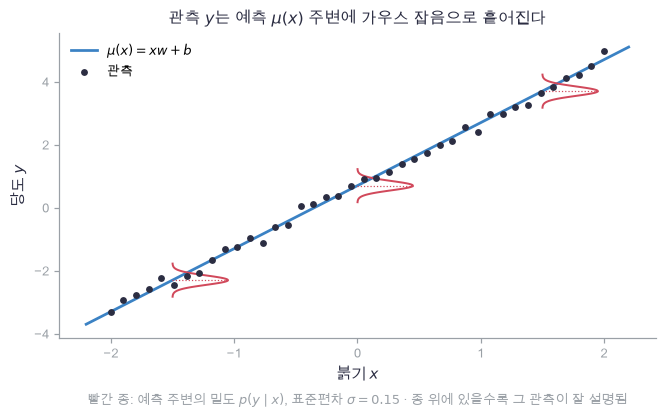

In [30]:
plot_gaussian_observation(fruit_x.ravel(), fruit_y.ravel(), line_x, line_mu, sigma_true, bell_at, bell_mu)

🔍 **확인** · 빨간 종이 "이 붉기에서 당도가 나올 밀도"입니다. 종의 가운데가 직선의 예측이고, 관측이 종의 높은 곳에 있을수록 밀도가 큽니다.
모든 관측의 밀도를 곱한 것이 우도이고, $-\log$를 붙이면 $(y-\mu)^2/2\sigma^2$의 합이 남습니다. **잔차를 제곱하는 이유가 종 모양의 지수 안에 이미 들어 있습니다.**
직선을 잘못 두면 관측들이 종의 꼬리로 밀려나 밀도가 작아지고 손실이 커집니다.

In [31]:
def gaussian_nll(prediction, target, sigma=1.0):
    """가우스 관측 모형의 NLL 평균: J = ½ log(2πσ²) + (1/2σ²M) Σ (μ − y)².
    prediction(μ), target(y): 같은 모양 (N, K), sigma: 양수 → 숫자 하나."""
    assert sigma > 0, "표준편차는 양수여야 합니다"
    assert prediction.shape == target.shape, "예측과 정답은 같은 모양이어야 합니다"
    residual = prediction - target                      # (N, K): μ − y
    return 0.5 * np.log(2 * np.pi * sigma**2) + 0.5 * np.mean(residual**2) / sigma**2


def gaussian_mean_gradient(prediction, target, sigma=1.0):
    """위 J의 예측에 대한 미분: ∂J/∂μ_i = (μ_i − y_i)/(σ² M). prediction, target: (N, K) → (N, K)."""
    return (prediction - target) / (prediction.size * sigma**2)

In [32]:
prediction = np.array([[1.], [2.], [4.]])                # (3, 1): 예측 μ
target = np.array([[0.], [2.], [3.]])                    # (3, 1): 정답 y. 잔차 [1, 0, 1]
half_mse = 0.5 * np.mean((prediction - target)**2)
np.testing.assert_allclose(half_mse, 1/3)                # 검산: 0.5·(1 + 0 + 1)/3
np.testing.assert_allclose(gaussian_nll(prediction, target), 0.5*np.log(2*np.pi) + 1/3)   # 검산: σ = 1이면 상수항 + 절반 MSE


def gaussian_objective(mu):
    """검사기용: 예측 mu만 바꿨을 때의 Gaussian NLL (σ = 0.7). mu: (3, 1) → 숫자 하나."""
    return np.array(gaussian_nll(mu, target, sigma=0.7))


def gaussian_backward(dout, mu):
    """검사기용: 손으로 유도한 ∂J/∂μ에 상류 기울기 dout을 곱한 것. → (3, 1)."""
    return dout * gaussian_mean_gradient(mu, target, sigma=0.7)


gaussian_error = check_function(gaussian_objective, gaussian_backward, prediction,
                                dout=np.array(1.0), verbose=True, name="Gaussian NLL → 평균")   # 중심차분과 대조 (01번 5절)
print("절반 MSE", half_mse, "· Gaussian NLL", gaussian_nll(prediction, target))

[gradcheck] Gaussian NLL → 평균
  ok   dx  rel_err = 3.596e-10
절반 MSE 0.3333333333333333 · Gaussian NLL 1.252271866538006


### ✏️ 연습 6 · 종 모양 밀도에서 NLL로

예측 `prediction`(수식의 $\mu$)과 정답 `target`(수식의 $y$)이 같은 모양 `(N, K)`일 때, 관측마다 가우스 밀도 $p(y\mid x)$를 계산하는 `density` 한 줄을 채우세요. 인자 순서는 본문 `gaussian_nll(prediction, target)`과 같습니다. 검사는 밀도의 $-\log$를 평균낸 값이 본문 `gaussian_nll`과 같은지도 봅니다. 잔차를 제곱하는 이유가 이 한 줄의 지수 안에 있습니다.

In [33]:
def exercise_gaussian_density(prediction, target, sigma=1.0):
    """연습 6: 가우스 관측 모형의 밀도 p(y | x). prediction(μ), target(y): 같은 모양 (N, K), sigma: 양수 → 같은 모양의 밀도."""
    assert sigma > 0, "표준편차는 양수여야 합니다"
    assert prediction.shape == target.shape, "예측과 정답은 같은 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 관측마다 밀도 exp[−(y − μ)² / (2σ²)] / (√(2π) σ)
    ### 힌트: 6절 첫 수식이고, 계산 셀의 density_at_points 한 줄입니다. np.exp, np.sqrt, np.pi를 씁니다.
    raise NotImplementedError
    return density

In [34]:
def check_gaussian_density(candidate):
    """6절 검산 예제의 잔차 [1, 0, 1]로 밀도를 검사하고, 밀도의 −log 평균이 6절의 NLL과 같은지 봅니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: gaussian_nll (6절)
    example_prediction = np.array([[1.], [2.], [4.]])          # (3, 1): 예측 μ
    example_target = np.array([[0.], [2.], [3.]])              # (3, 1): 정답 y. 잔차 [1, 0, 1]
    density = candidate(example_prediction, example_target)
    assert density.shape == (3, 1), f"밀도는 입력과 같은 (3, 1)이어야 하는데 {density.shape}입니다"
    np.testing.assert_allclose(density.ravel(), [0.24197, 0.39894, 0.24197], rtol=1e-4)   # 검산: e^−0.5/√(2π) ≈ 0.242, 1/√(2π) ≈ 0.399
    np.testing.assert_allclose(-np.log(density).mean(), gaussian_nll(example_prediction, example_target))   # 검산: 밀도의 −log 평균 = 6절 NLL
    narrow = candidate(example_prediction, example_target, sigma=0.5)
    np.testing.assert_allclose(narrow[1, 0], 0.79788, rtol=1e-4)     # 검산: 잔차 0에서 1/(√(2π)·0.5). 종이 좁으면 가운데가 높음
    print("가우스 밀도: 손계산과 일치합니다.")

run_check(check_gaussian_density, exercise_gaussian_density, hint="density = np.exp(-0.5 * ((target - prediction) / sigma) ** 2) / (np.sqrt(2 * np.pi) * sigma)")

☐ exercise_gaussian_density: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: density = np.exp(-0.5 * ((target - prediction) / sigma) ** 2) / (np.sqrt(2 * np.pi) * sigma)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
density = np.exp(-0.5 * ((target - prediction) / sigma) ** 2) / (np.sqrt(2 * np.pi) * sigma)
```

</details>

## 🔑 7. Bernoulli 모형에서 BCE와 logit 기울기를 얻습니다

**이 절에서 가져갈 것:** 예/아니오 관측에는 sigmoid로 만든 확률 $p$를 쓰고, 손실은 정답 쪽 확률의 $-\log$입니다. 점수 $z$에 대한 기울기는 $p-y$입니다.

"이 이미지가 7인가"는 예/아니오 관측입니다. 5절의 고정 확률 $\theta$ 대신 이미지마다 다른 확률 $p_n=\sigma(z_n)$를 씁니다.

> **용어**
>
> - **logit** $z$: 모델이 내는 실수 점수. 00번의 $x\cdot w+b$. 음수도 양수도 될 수 있습니다.
> - **sigmoid** $\sigma(z)=1/(1+e^{-z})$: 실수 점수를 0과 1 사이의 확률로 바꾸는 함수. $z=0$이면 0.5.
> - **BCE(binary cross-entropy)**: 0/1 관측의 NLL. $-y\log p-(1-y)\log(1-p)$, 곧 "정답 쪽 확률의 $-\log$".

$$p=\sigma(z)=\frac1{1+e^{-z}},\quad\frac{dp}{dz}=p(1-p),\quad
\ell=-y\log p-(1-y)\log(1-p).$$

연쇄법칙을 한 줄씩 연결하면

$$\frac{\partial\ell}{\partial p}=-\frac yp+\frac{1-y}{1-p},\qquad
\frac{\partial\ell}{\partial z}=\left(-\frac yp+\frac{1-y}{1-p}\right)p(1-p)=p-y.$$

sigmoid의 미분도 $p=(1+e^{-z})^{-1}$에 연쇄법칙을 적용하면 $p'=e^{-z}/(1+e^{-z})^2=p(1-p)$로 얻습니다.
평균 손실에서는 전체 스칼라 라벨 수 $M$으로 나눕니다. 아래 예제는 `(N,1)`이므로 $M=N$입니다.

📎 확률을 먼저 계산해 `log(p)`에 넣으면 큰 logit에서 반올림으로 p가 0 또는 1이 될 수 있습니다. 같은 식을 logit으로 정리합니다.

$$\ell=\log(1+e^z)-yz=\max(z,0)-yz+\log(1+e^{-|z|}).$$

`np.logaddexp(0, z)`는 $\log(e^0+e^z)$를 안정적으로 계산합니다.


In [35]:
# 쓰는 것: mnist_Xe, mnist_labels, templates (📎 데이터 셀)
z_seven = 0.4 * (mnist_Xe @ templates[:, 7])          # (10,): 7 템플릿 점수 z. 0.4배는 확률이 0·1에 붙지 않게 하려는 것
p_seven = 1 / (1 + np.exp(-z_seven))                    # (10,): sigmoid → "7일 확률"
y_seven = (mnist_labels == 7).astype(float)             # (10,): 정답. 7이면 1
loss_each = -(y_seven * np.log(p_seven) + (1 - y_seven) * np.log(1 - p_seven))   # (10,): 이미지마다 −log(정답 쪽 확률)
np.testing.assert_allclose(loss_each[7], -np.log(p_seven[7]))   # 검산: 정답이 1인 7은 −log p
print("확률", p_seven.round(2))
print("손실", loss_each.round(2), "· 평균", loss_each.mean().round(3))

확률 [0.05 0.09 0.25 0.03 0.25 0.21 0.04 0.93 0.16 0.69]
손실 [0.06 0.09 0.29 0.03 0.29 0.24 0.04 0.08 0.17 1.17] · 평균 0.246


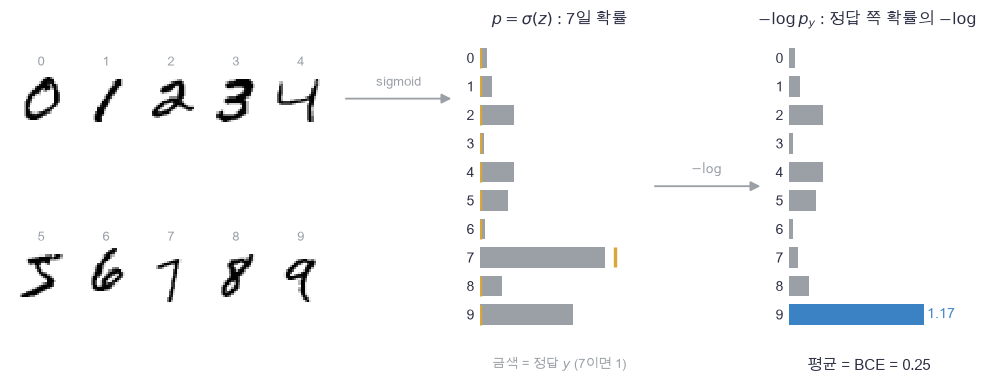

In [36]:
plot_bce_examples(mnist_examples, p_seven, y_seven, loss_each, mnist_labels)

🔍 **확인** · 가운데는 sigmoid로 만든 "7일 확률"이고 금색 눈금이 정답입니다. 오른쪽은 이미지마다 정답 쪽 확률의 $-\log$입니다.
7은 확률 0.93으로 정답 1에 가까워 손실이 작고, 9는 7이 아닌데 확률 0.69를 주어 손실이 가장 큽니다. **틀린 쪽에 확신할수록 손실이 크게 벌을 줍니다.**
이 손실을 줄이려면 9의 점수는 내리고 7의 점수는 올려야 하는데, 기울기 $p-y$가 정확히 그 방향입니다(9: $+0.69$, 7: $-0.07$).

In [37]:
def sigmoid(logits):
    """σ(z) = 1/(1 + e^−z)를 큰 |z|에서도 넘치지 않게: 항상 e^−|z| ≤ 1만 계산합니다. logits: 어떤 모양 → 같은 모양의 확률."""
    logits = np.asarray(logits, dtype=float)
    exp_negative_abs = np.exp(-np.abs(logits))          # e^−|z|: 0과 1 사이라 절대 넘치지 않음
    return np.where(logits >= 0,
                    1 / (1 + exp_negative_abs),         # z ≥ 0: 원래 식 그대로
                    exp_negative_abs / (1 + exp_negative_abs))   # z < 0: 분자·분모에 e^z를 곱한 같은 식


def bce_with_logits(logits, targets):
    """평균 BCE를 logit으로 안정적으로: J = mean(log(1 + e^z) − y z), 기울기 dZ = (σ(z) − y)/M.
    logits, targets: 같은 모양 (N, K) → (J: 숫자, dZ: (N, K))."""
    assert logits.shape == targets.shape, "logit과 정답은 같은 모양이어야 합니다"
    loss = np.mean(np.logaddexp(0.0, logits) - targets * logits)   # logaddexp(0, z) = log(e^0 + e^z)
    gradient = (sigmoid(logits) - targets) / targets.size          # (N, K): p − y를 원소 수 M으로 나눔
    return float(loss), gradient

In [38]:
# 쓰는 것: bernoulli_nll (5절)
logits = np.array([[0.], [np.log(3.)]])                  # (2, 1): 점수 두 개. σ(0) = 0.5, σ(log 3) = 0.75
labels = np.array([[0.], [1.]])                          # (2, 1): 정답
bce_loss, bce_gradient = bce_with_logits(logits, labels)
np.testing.assert_allclose(sigmoid(logits).ravel(), [0.5, 0.75])            # 검산: sigmoid 손계산
np.testing.assert_allclose(bce_loss, (-np.log(0.5) - np.log(0.75))/2)      # 검산: 정답 쪽 확률의 −log 평균
np.testing.assert_allclose(bce_gradient, [[0.25], [-0.125]])                # 검산: (p − y)/M = (0.5 − 0)/2, (0.75 − 1)/2
np.testing.assert_allclose(bce_loss, bernoulli_nll(sigmoid(logits), labels))   # 검산: 5절의 확률 기반 NLL과 같은 값


def bce_objective(z):
    """검사기용: logit z만 바꿨을 때의 평균 BCE. z: (2, 1) → 숫자 하나."""
    return np.array(bce_with_logits(z, labels)[0])


def bce_backward(dout, z):
    """검사기용: 손으로 유도한 (p − y)/M에 상류 기울기 dout을 곱한 것. → (2, 1)."""
    return dout * bce_with_logits(z, labels)[1]


bce_error = check_function(bce_objective, bce_backward, logits,
                           dout=np.array(1.0), verbose=True, name="BCE → logits")
print("BCE", bce_loss, "· 기울기", bce_gradient.ravel())

[gradcheck] BCE → logits
  ok   dx  rel_err = 6.989e-11
BCE 0.49041462650586315 · 기울기 [ 0.25  -0.125]


In [39]:
extreme_z = np.array([[-1000.], [1000.]])                # (2, 1): 극단적인 logit. 둘 다 정답과 반대 쪽
extreme_y = np.array([[1.], [0.]])
extreme_loss, extreme_gradient = bce_with_logits(extreme_z, extreme_y)
assert np.isfinite(extreme_loss), "logit으로 계산하면 큰 점수에서도 손실이 유한해야 합니다"
assert np.all(np.isfinite(extreme_gradient)), "기울기도 유한해야 합니다"
np.testing.assert_allclose(extreme_loss, 1000.0)         # 검산: max(z, 0) − yz = 1000이 둘 다 → 평균 1000
print("극단적인 오답 logit의 손실", extreme_loss, "· 기울기", extreme_gradient.ravel())

극단적인 오답 logit의 손실 1000.0 · 기울기 [-0.5  0.5]


In [40]:
z_grid = np.linspace(-8, 8, 201)                                        # (201,): 그림용 logit 좌표
loss_curves = {"y=0": np.logaddexp(0, z_grid), "y=1": np.logaddexp(0, z_grid)-z_grid}   # 한 표본의 BCE ℓ(z)
gradient_curves = {"y=0": sigmoid(z_grid), "y=1": sigmoid(z_grid)-1}   # 그 미분 p − y

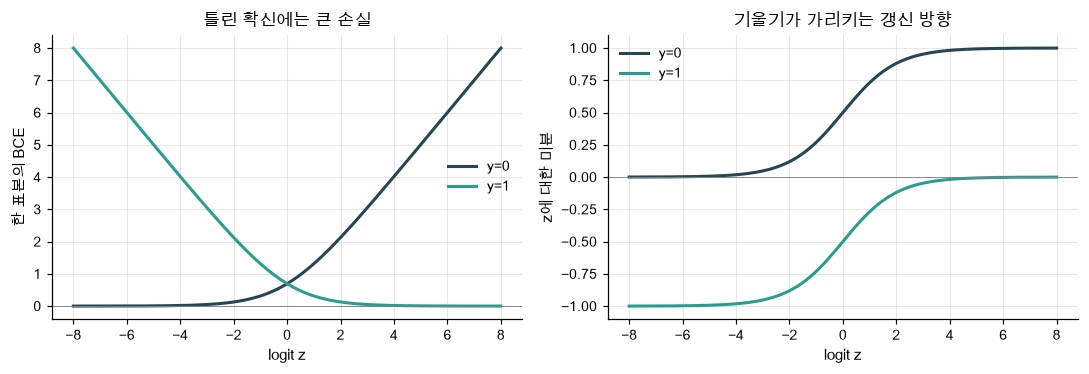

In [41]:
plot_loss_curves(z_grid, loss_curves, gradient_curves)

🔍 **확인** · 왼쪽은 정답이 0일 때와 1일 때 한 표본의 BCE, 오른쪽은 $z$에 대한 미분 $p-y$입니다.
y=1인데 z가 큰 음수이면 미분은 약 −1입니다. 경사하강에서 이 음수를 빼면 z가 커집니다. 확률이 정답 쪽으로 움직이는지 부호로 검산할 수 있습니다.
위 검산에서 `dout=1`을 명시한 것은 스칼라 손실 자체를 미분한다는 뜻입니다.

### ✏️ 연습 7 · 정답 쪽 확률의 −log와 p − y

확률 `probability = sigmoid(logits)`는 미리 만들어 두었습니다. 표본마다 정답 쪽 확률의 $-\log$인 `loss_each`와, 점수 $z$에 대한 기울기 `gradient` $= p - y$ 두 줄을 채우세요. 노트북 끝의 연습 B가 logit으로 정리한 **평균** 손실을 묻는 것과 달리, 여기서는 확률 $p$로 쓴 **표본별** 값이고 원소 수 $M$으로 나누지 않습니다.

In [42]:
def exercise_bce_from_probability(logits, targets):
    """연습 7: 확률로 쓴 표본별 BCE와 logit 기울기. logits, targets: 같은 모양 (N, K) → (loss_each: (N, K), gradient: (N, K))."""
    assert logits.shape == targets.shape, "logit과 정답은 같은 모양이어야 합니다"
    probability = sigmoid(logits)                   # (N, K): p = σ(z). 7절 함수
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 표본마다 정답 쪽 확률의 −log인 loss_each = −[y log p + (1 − y) log(1 − p)]와, 점수 z에 대한 기울기 gradient = p − y (평균 없이 표본별로)
    ### 힌트: 7절 계산 셀의 loss_each 한 줄과 수식 ∂ℓ/∂z = p − y입니다. 원소 수 M으로 나누지 않습니다.
    raise NotImplementedError
    return loss_each, gradient

In [43]:
def check_bce_from_probability(candidate):
    """σ(z) = 0.5, 0.75, 0.25인 logit 세 개로 검사하고, 평균하면 7절의 logit 판과 같은지 봅니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: bce_with_logits (7절)
    example_logits = np.array([[0.], [np.log(3.)], [-np.log(3.)]])   # (3, 1): σ(z) = 0.5, 0.75, 0.25
    example_targets = np.array([[0.], [1.], [1.]])                    # (3, 1): 정답
    loss_each, gradient = candidate(example_logits, example_targets)
    assert loss_each.shape == (3, 1), f"표본별 손실은 (3, 1)이어야 하는데 {loss_each.shape}입니다"
    np.testing.assert_allclose(loss_each.ravel(), [np.log(2), -np.log(0.75), np.log(4)])   # 검산: 정답 쪽 확률 0.5, 0.75, 0.25의 −log
    np.testing.assert_allclose(gradient, [[0.5], [-0.25], [-0.75]])                          # 검산: p − y = 0.5 − 0, 0.75 − 1, 0.25 − 1
    mean_loss, mean_gradient = bce_with_logits(example_logits, example_targets)
    np.testing.assert_allclose(loss_each.mean(), mean_loss)                                  # 검산: 표본별 손실의 평균 = logit 판 평균 BCE
    np.testing.assert_allclose(gradient / example_targets.size, mean_gradient)              # 검산: (p − y)/M = logit 판 기울기
    print("확률로 쓴 BCE와 p − y: 손계산과 일치합니다.")

run_check(check_bce_from_probability, exercise_bce_from_probability, hint="loss_each = -(targets * np.log(probability) + (1 - targets) * np.log(1 - probability)); gradient = probability - targets")

☐ exercise_bce_from_probability: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: loss_each = -(targets * np.log(probability) + (1 - targets) * np.log(1 - probability)); gradient = probability - targets


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
loss_each = -(targets * np.log(probability) + (1 - targets) * np.log(1 - probability))
gradient = probability - targets
```

</details>

## 🔑 8. Categorical 모형에서 softmax CE를 얻습니다

**이 절에서 가져갈 것:** K개 중 하나를 고르는 관측에는 softmax로 만든 확률 K개를 쓰고, 손실은 정답 클래스 확률의 $-\log$입니다. 기울기는 역시 "확률 − 정답", `(P - T) / N`.

"이 이미지는 0부터 9 중 어느 숫자인가"는 열 가지 중 **정확히 하나**를 고르는 관측입니다. 점수가 열 개 $z_0,\ldots,z_9$ 나오므로, 열 개를 한꺼번에 확률로 바꿔야 합니다.

> **용어**
>
> - **softmax**: 점수 K개를 지수로 양수로 만들고 합으로 나누어 "합이 1인 확률 K개"로 바꾸는 함수. 큰 점수가 큰 확률이 됩니다.
> - **one-hot**: 정답을 길이 K 벡터로 쓴 것. 정답 자리만 1, 나머지 0. $T_{nk}=1[k=y_n]$.
> - **cross-entropy(CE)**: 정답 클래스 확률의 $-\log$. one-hot과 $\log P$를 곱해 더한 것과 같습니다.

$$P_{nk}=\frac{e^{Z_{nk}}}{\sum_j e^{Z_{nj}}},\qquad
J=-\frac1N\sum_n\log P_{n,y_n}=-\frac1N\sum_{n,k}T_{nk}\log P_{nk}.$$

한 행의 확률을 합하면 1입니다. **클래스 축은 합하고, 샘플 축은 평균냅니다. 분모는 NK가 아니라 N입니다.**

한 행에서 $\ell=\log\sum_j e^{z_j}-z_y$이므로

$$\frac{\partial\ell}{\partial z_k}=\frac{e^{z_k}}{\sum_j e^{z_j}}-1[k=y]=p_k-t_k.$$

따라서 `dZ=(P-T)/N`입니다. 📎 여러 개의 독립 이진 라벨을 예측하는 다중라벨 문제라면 각 출력에 BCE를 쓰며, 위의 한 클래스 선택 모형과 구분합니다.

📎 수치 계산에서는 행의 최댓값 m을 빼서 $\log P_k=(z_k-m)-\log\sum_j e^{z_j-m}$로 만듭니다. 확률은 공통 상수를 빼도 같으며 지수에 큰 양수가 들어가지 않습니다.

> **코드**
>
> - `mnist_Xe[pick]`: 번호 목록 `[7, 3]`으로 행 두 개를 고릅니다(정수 배열 인덱싱).
> - `P_pick[np.arange(2), pick]`: `(0, 7)`, `(1, 3)` 두 칸을 한 번에 고릅니다. 행 n의 정답 열 y_n을 짝지어 고르는 "쌍으로 고르기"이고, 반복문으로는 `for n: P[n, y[n]]`입니다.
> - `gradient = probabilities.copy()` 뒤 `gradient[rows, targets] -= 1`: 확률표를 복사한 뒤 정답 칸에서만 1을 뺍니다. 수식의 $P - T$를 one-hot 행렬 없이 쓴 것입니다.

In [44]:
# 쓰는 것: mnist_Xe, templates (📎 데이터 셀)
pick = [7, 3]                                             # 예시 7과 예시 3 (행 번호 = 정답 숫자)
Z_pick = mnist_Xe[pick] @ templates                       # (2, 10): 열 숫자의 템플릿 점수
shifted = Z_pick - Z_pick.max(axis=1, keepdims=True)      # (2, 10): 행마다 최댓값을 빼 지수가 넘치지 않게
P_pick = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)   # (2, 10): softmax, 행마다 합 1
ce_each = -np.log(P_pick[np.arange(2), pick])             # (2,): 정답 확률의 −log
np.testing.assert_allclose(P_pick.sum(axis=1), 1)        # 검산: 행마다 확률 합 1
print("확률\n", P_pick.round(3))
print("CE", ce_each.round(3))

확률
 [[0.    0.    0.    0.    0.    0.    0.    0.728 0.02  0.251]
 [0.004 0.    0.    0.406 0.    0.    0.    0.    0.59  0.   ]]
CE [0.317 0.901]


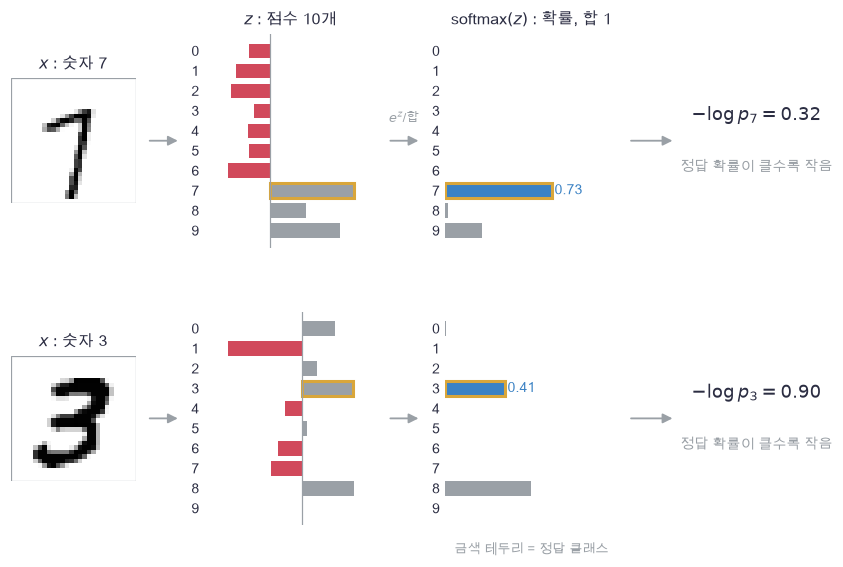

In [45]:
plot_softmax_examples(mnist_examples[pick], Z_pick, P_pick, pick, ce_each)

🔍 **확인** · 점수 열 개는 음수도 있고 크기도 제각각이지만, softmax를 거치면 모두 양수이고 합이 1인 확률이 됩니다. 점수의 순서는 그대로입니다.
7은 정답 확률 0.73으로 손실이 작고, 3은 템플릿이 8과 헷갈려 정답 확률이 0.41이라 손실이 큽니다. 학습은 정답 자리의 확률을 키우도록 점수를 고칩니다.
기울기 $p_k-t_k$는 정답 자리에서는 음수(점수를 올려라), 다른 자리에서는 양수(내려라)입니다.

In [46]:
def log_softmax(logits):
    """행마다 log P_k = (z_k − m) − log Σ_j e^(z_j − m), m은 행의 최댓값. logits: (N, K) → (N, K)."""
    shifted = logits - logits.max(axis=1, keepdims=True)                 # (N, K): 행마다 최댓값을 뺌
    return shifted - np.log(np.exp(shifted).sum(axis=1, keepdims=True))  # (N, K) − (N, 1)


def softmax_cross_entropy(logits, targets):
    """softmax cross-entropy 평균과 logit 기울기: J = −(1/N) Σ_n log P[n, y_n], dZ = (P − T)/N.
    logits: (N, K), targets: (N,) 정수 라벨 → (J: 숫자, dZ: (N, K))."""
    N, K = logits.shape
    assert targets.shape == (N,), "정답은 (N,) 정수 배열이어야 합니다"
    assert np.issubdtype(targets.dtype, np.integer), "정답은 정수 타입이어야 인덱스로 쓸 수 있습니다"
    assert np.all((0 <= targets) & (targets < K)), "정답은 0 이상 K 미만이어야 합니다"
    log_probabilities = log_softmax(logits)                # (N, K)
    probabilities = np.exp(log_probabilities)              # (N, K): P
    rows = np.arange(N)                                    # rows[n]과 targets[n]을 한 쌍으로 선택합니다
    loss = -log_probabilities[rows, targets].mean()        # 정답 자리 N개의 −log를 평균
    gradient = probabilities.copy()                        # (N, K): P에서 시작해
    gradient[rows, targets] -= 1                           #   정답 자리만 1을 빼면 P − T
    gradient /= N                                          #   샘플 평균이므로 N으로 나눔
    return float(loss), gradient

In [47]:
class_logits = np.array([[0., 0., 0.], [np.log(2), 0., 0.]])   # (2, 3): 점수. 둘째 행은 e^(log 2) = 2로 2:1:1
class_targets = np.array([2, 0])                                # (2,): 정답 클래스
ce_loss, ce_gradient = softmax_cross_entropy(class_logits, class_targets)
class_probabilities = np.exp(log_softmax(class_logits))
np.testing.assert_allclose(class_probabilities, [[1/3, 1/3, 1/3], [0.5, 0.25, 0.25]])   # 검산: softmax 손계산
np.testing.assert_allclose(ce_loss, (np.log(3)+np.log(2))/2)                            # 검산: −log(1/3), −log(1/2)의 평균
np.testing.assert_allclose(ce_gradient, [[1/6, 1/6, -1/3], [-0.25, 0.125, 0.125]])      # 검산: (P − T)/N, 정답 자리는 음수
np.testing.assert_allclose(ce_gradient.sum(axis=1), 0, atol=1e-15)                       # 검산: 행마다 기울기 합 0 (Σp = Σt = 1)
np.testing.assert_allclose(log_softmax(class_logits + 10000), log_softmax(class_logits), atol=1e-11)   # 검산: 공통 상수를 더해도 같음


def ce_objective(z):
    """검사기용: logit z만 바꿨을 때의 softmax CE. z: (2, 3) → 숫자 하나."""
    return np.array(softmax_cross_entropy(z, class_targets)[0])


def ce_backward(dout, z):
    """검사기용: 손으로 유도한 (P − T)/N에 상류 기울기 dout을 곱한 것. → (2, 3)."""
    return dout * softmax_cross_entropy(z, class_targets)[1]


ce_error = check_function(ce_objective, ce_backward, class_logits,
                          dout=np.array(1.), verbose=True, name="softmax CE → logits")
print("클래스 확률:\n", class_probabilities)
print("CE", ce_loss, "· dZ:\n", ce_gradient)

[gradcheck] softmax CE → logits
  ok   dx  rel_err = 1.398e-10
클래스 확률:
 [[0.33333 0.33333 0.33333]
 [0.5     0.25    0.25   ]]
CE 0.8958797346140275 · dZ:
 [[ 0.16667  0.16667 -0.33333]
 [-0.25     0.125    0.125  ]]


<Axes: ylabel='상대오차'>

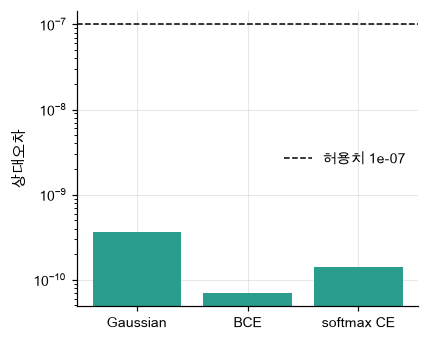

In [48]:
plot_gradcheck({"Gaussian": gaussian_error, "BCE": bce_error, "softmax CE": ce_error})

🔍 **확인** · 검산한 것은 같은 손실의 수식과 코드 미분이 작은 입력에서 일치하는지입니다. 데이터에 적절한 관측 모형인지까지 수치미분이 판단해 주지는 않습니다.

### ✏️ 연습 8 · 점수 K개를 확률 K개로

점수 `logits` `(N, K)`에서 행마다 최댓값을 뺀 `shifted`와, 그 지수를 행의 지수 합으로 나눈 확률 `P` `(N, K)` 두 줄을 채우세요. 노트북 끝의 연습 C는 `log_softmax`를 주고 손실·기울기를 묻지만, 여기서는 softmax 자체입니다. 검사는 점수에 1000을 더해도 같은 확률이 유한하게 나오는지도 봅니다.

In [49]:
def exercise_softmax(logits):
    """연습 8: 행마다 점수 K개를 합이 1인 확률 K개로. logits: (N, K) → P: (N, K)."""
    assert logits.ndim == 2, "logits는 (N, K) 2차원 배열이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 행마다 최댓값을 뺀 shifted (N, K)와, 그 지수를 행의 지수 합으로 나눈 P (N, K, 행마다 합 1)
    ### 힌트: 8절 계산 셀의 shifted와 P_pick 두 줄입니다. 클래스 축을 따라 최댓값·합을 내려면 axis=1, keepdims=True로 (N, 1)을 유지합니다.
    raise NotImplementedError
    return P

In [50]:
def check_softmax(candidate):
    """8절 검산 예제의 점수 (2, 3)으로 확률을 검사하고, 큰 점수에서도 유한한지 봅니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: log_softmax (8절)
    example_logits = np.array([[0., 0., 0.], [np.log(2), 0., 0.]])   # (2, 3): 8절 검산 예제. 둘째 행은 2:1:1
    P = candidate(example_logits)
    assert P.shape == (2, 3), f"확률은 점수와 같은 (2, 3)이어야 하는데 {P.shape}입니다"
    np.testing.assert_allclose(P, [[1/3, 1/3, 1/3], [0.5, 0.25, 0.25]])   # 검산: 손계산. 같은 점수는 같은 확률, 2:1:1은 0.5:0.25:0.25
    np.testing.assert_allclose(P.sum(axis=1), 1)                          # 검산: 행마다 합 1
    big_P = candidate(example_logits + 1000)
    assert np.all(np.isfinite(big_P)), "큰 점수에서도 확률이 유한해야 합니다 (행의 최댓값을 뺐는지 확인)"
    np.testing.assert_allclose(big_P, P)                                  # 검산: 공통 상수를 더해도 확률은 같음
    np.testing.assert_allclose(P, np.exp(log_softmax(example_logits)))    # 검산: 8절 log_softmax의 지수와 같음
    print("softmax: 손계산과 일치합니다.")

run_check(check_softmax, exercise_softmax, hint="shifted = logits - logits.max(axis=1, keepdims=True); P = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)")

☐ exercise_softmax: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: shifted = logits - logits.max(axis=1, keepdims=True); P = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
shifted = logits - logits.max(axis=1, keepdims=True)
P = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)
```

</details>

## 🔍 9. 목적함수를 실제 분류 학습에 연결합니다

작은 이진 분류 문제에서 $z_n=x_n w+b$, $p_n=\sigma(z_n)$로 놓습니다.
BCE가 반환한 `dZ`에 이미 평균이 들어 있으므로 01처럼 `dW=X.T @ dZ`, `db=dZ.sum(axis=0)`를 계산합니다.

| 이름 | shape | 의미 |
|---|---|---|
| X, Y, Z | `(N, 1)` | 입력, 라벨, logit |
| W, b | `(1, 1)`, `(1,)` | 가중치, 편향 |
| dZ | `(N, 1)` | 평균 BCE의 logit 기울기 |

라벨은 이 작은 고정 예제를 이해하기 위해 직접 정했습니다. 03번에서 비선형 분류를 다룹니다.


In [51]:
def train_logistic(X, Y, steps=400, learning_rate=0.2):
    """로지스틱 회귀를 경사하강으로 steps번 갱신: z = XW + b → 평균 BCE와 dZ → dW = Xᵀ dZ, db = Σ dZ → W −= η dW.
    X: (N, D), Y: (N, 1) 0/1 → (W: (D, 1), b: (1,), losses: (steps+1,) 갱신 전 손실부터)."""
    # 쓰는 것: bce_with_logits (7절)
    W, b = np.zeros((X.shape[1], 1)), np.zeros(1)          # 0에서 시작
    losses = []
    for step in range(steps + 1):                           # 마지막 바퀴는 손실만 기록
        logits = X @ W + b                                  # 1. 예측 (N, 1)
        loss, dZ = bce_with_logits(logits, Y)               # 2. 손실과 logit 기울기 (평균 포함)
        losses.append(loss)
        if step == steps:
            break
        dW = X.T @ dZ                                       # 3. 기울기 (01번과 같은 두 줄)
        db = dZ.sum(axis=0)
        W -= learning_rate * dW                             # 4. 갱신
        b -= learning_rate * db
    return W, b, np.array(losses)

In [52]:
# 쓰는 것: sigmoid (7절)
X_train = np.array([[-2.], [-1.5], [-1.], [-0.5], [0.3], [0.8], [1.2], [2.]])   # (8, 1): 입력
Y_train = np.array([[0.], [0.], [0.], [0.], [1.], [1.], [1.], [1.]])           # (8, 1): 라벨. 음수면 0, 양수면 1
W, b, training_losses = train_logistic(X_train, Y_train)
train_probabilities = sigmoid(X_train @ W + b)                      # (8, 1): 학습 뒤 확률
accuracy = np.mean((train_probabilities >= 0.5) == Y_train)         # 임계값 0.5로 고른 클래스가 라벨과 같은 비율
assert training_losses[-1] < training_losses[0] / 5, "400스텝 뒤 손실이 처음의 1/5 아래여야 합니다"
assert accuracy == 1.0, "선형 분리 가능한 8개 점은 모두 맞혀야 합니다"
print(f"학습 손실 {training_losses[0]:.6f} → {training_losses[-1]:.6f}, 학습 정확도 {accuracy:.1%}")
print("W", W.ravel(), "b", b)
curve_x = np.linspace(-2.3, 2.3, 200)[:, None]                      # (200, 1): 그림용 입력 좌표
curve_probability = sigmoid(curve_x @ W + b)                        # (200, 1): 학습한 확률 곡선

학습 손실 0.693147 → 0.043524, 학습 정확도 100.0%
W [4.48523] b [0.39428]


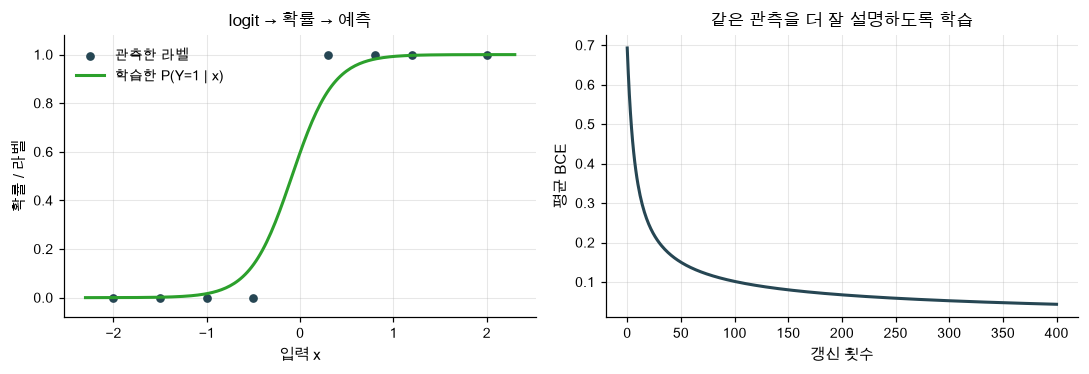

In [53]:
plot_classifier(X_train.ravel(), Y_train.ravel(), curve_x.ravel(), curve_probability.ravel(), training_losses)

🔍 **확인** · 여기의 정확도는 **학습에 쓴 8개 점**에서 측정했습니다. 새로운 데이터에 대한 성능을 측정한 값은 아닙니다.
또한 선형 분리 가능한 이 데이터의 BCE는 가중치 크기를 계속 늘려 더 작게 만들 수 있으므로, 유한한 최적 가중치를 찾았다고 해석하지 않습니다.
학습은 logit과 확률을 만들고, 실제 클래스 선택은 마지막의 임계값 0.5로 수행합니다.

## ✏️ 10. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 기댓값 (1절)

값이 `[0, 2, 5]`, 확률이 `[0.5, 0.25, 0.25]`라면 기댓값은 1.75입니다. 확률 가중합 한 줄을 채우세요.

In [54]:
def exercise_expectation(values, probabilities):
    """연습 A: 기댓값 Σ p_i a_i. values, probabilities: (n,) → 숫자 하나."""
    values = np.asarray(values, dtype=float)
    probabilities = np.asarray(probabilities, dtype=float)
    assert values.shape == probabilities.shape, "값과 확률은 같은 개수여야 합니다"
    assert np.isclose(probabilities.sum(), 1), "확률의 합은 1이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 값 × 확률을 모두 더한 기댓값 (스칼라)
    ### 힌트: 1절의 expectation 함수 마지막 줄입니다.
    raise NotImplementedError
    return result

In [55]:
def check_expectation(candidate):
    """손계산 예제 둘로 검사합니다. 통과하면 메시지를 출력합니다."""
    np.testing.assert_allclose(candidate(np.array([0., 2., 5.]), np.array([0.5, 0.25, 0.25])), 1.75)   # 검산: 0 + 0.5 + 1.25
    np.testing.assert_allclose(candidate(np.array([-1., 3.]), np.array([0.25, 0.75])), 2.0)             # 검산: −0.25 + 2.25
    print("기댓값 변형: 손계산과 일치합니다.")

run_check(check_expectation, exercise_expectation, hint="result = np.sum(values * probabilities)")

☐ exercise_expectation: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: result = np.sum(values * probabilities)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
result = np.sum(values * probabilities)
```

</details>

### ✏️ 연습 B · logit으로 쓴 BCE와 기울기 (7절)

평균 BCE를 logit으로 안정적으로 계산하는 줄과, logit에 대한 기울기 `(p − y) / M` 줄을 채우세요. `sigmoid`는 본문 함수를 씁니다.

In [56]:
def exercise_bce_with_logits(logits, targets):
    """연습 B: logit으로 쓴 평균 BCE와 기울기. logits, targets: 같은 모양 (N, K) → (loss: 숫자, gradient: (N, K))."""
    assert logits.shape == targets.shape, "logit과 정답은 같은 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: loss = 평균( logaddexp(0, z) − y·z ), gradient = (sigmoid(z) − y) / 원소 수
    ### 힌트: np.logaddexp(0, logits)가 log(1 + e^z)입니다. 원소 수는 targets.size입니다.
    raise NotImplementedError
    return float(loss), gradient

In [57]:
def check_bce(candidate):
    """7절의 손계산 예제와 극단적인 logit으로 검사합니다. 통과하면 메시지를 출력합니다."""
    z = np.array([[0.], [np.log(3.)]])                                # (2, 1): σ(z) = 0.5, 0.75
    y = np.array([[0.], [1.]])
    loss, grad = candidate(z, y)
    np.testing.assert_allclose(loss, (-np.log(0.5) - np.log(0.75)) / 2)   # 검산: 정답 쪽 확률의 −log 평균
    np.testing.assert_allclose(grad, [[0.25], [-0.125]])                   # 검산: (p − y)/2
    big_loss, big_grad = candidate(np.array([[-1000.], [1000.]]), np.array([[1.], [0.]]))
    assert np.isfinite(big_loss) and np.all(np.isfinite(big_grad)), "큰 logit에서도 손실·기울기가 유한해야 합니다 (logaddexp를 썼는지 확인)"
    print("BCE: 손계산과 일치하고 큰 logit에서도 유한합니다.")

run_check(check_bce, exercise_bce_with_logits, hint="loss = np.mean(np.logaddexp(0.0, logits) - targets * logits); gradient = (sigmoid(logits) - targets) / targets.size")

☐ exercise_bce_with_logits: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: loss = np.mean(np.logaddexp(0.0, logits) - targets * logits); gradient = (sigmoid(logits) - targets) / targets.size


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
loss = np.mean(np.logaddexp(0.0, logits) - targets * logits)
gradient = (sigmoid(logits) - targets) / targets.size
```

</details>

### ✏️ 연습 C · 클래스가 4개인 softmax CE (8절)

`log_softmax`는 미리 써 두었습니다. 정답 자리의 로그 확률을 골라 평균내는 손실 줄과, 확률에서 정답 자리만 1을 빼는 기울기 줄을 채우세요.
logit이 모두 0이면 각 클래스의 확률은 1/4이고 정답의 기울기는 $(1/4-1)/N$입니다.

In [58]:
def exercise_softmax_cross_entropy(logits, targets):
    """연습 C: softmax CE 평균과 기울기. logits: (N, K), targets: (N,) 정수 → (loss: 숫자, gradient: (N, K))."""
    N, K = logits.shape
    assert targets.shape == (N,), "정답은 (N,) 배열이어야 합니다"
    assert np.all((0 <= targets) & (targets < K)), "정답은 0 이상 K 미만이어야 합니다"
    log_probabilities = log_softmax(logits)          # (N, K)
    probabilities = np.exp(log_probabilities)
    rows = np.arange(N)                              # rows[n]과 targets[n]이 한 쌍
    gradient = probabilities.copy()
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: loss = −(정답 자리 로그 확률)의 평균, 그리고 gradient의 정답 자리에서 1 빼기
    ### 힌트: log_probabilities[rows, targets]가 정답 자리 N개입니다. 기울기는 (P − T)/N 이므로 마지막에 N으로 나눕니다.
    raise NotImplementedError
    return loss, gradient / N

In [59]:
def check_ce(candidate):
    """클래스 4개 손계산, 배치를 두 배로 복제한 경우, 서로 다른 logit 한 행으로 검사합니다."""
    z = np.zeros((2, 4))                                   # (2, 4): 점수가 모두 0이면 확률은 1/4씩
    y = np.array([1, 3])
    loss, grad = candidate(z, y)
    expected = np.array([[1/8, -3/8, 1/8, 1/8], [1/8, 1/8, 1/8, -3/8]])   # (P − T)/N: 정답 자리 (1/4 − 1)/2, 나머지 (1/4)/2
    np.testing.assert_allclose(loss, np.log(4))            # 검산: −log(1/4)
    np.testing.assert_allclose(grad, expected)             # 검산: 위 손계산
    doubled_loss, doubled_grad = candidate(np.concatenate([z, z]), np.concatenate([y, y]))   # 같은 배치를 두 번 이어 붙임 (N = 4)
    np.testing.assert_allclose(doubled_loss, loss)         # 검산: 평균이므로 손실은 그대로
    np.testing.assert_allclose(doubled_grad[:2], grad / 2)  # 검산: N이 두 배라 기울기는 절반
    uneven_z = np.array([[np.log(3.), 0., 0., 0.]])        # (1, 4): e^(log 3) = 3이라 확률 3:1:1:1 = 0.5, 1/6, 1/6, 1/6
    uneven_loss, uneven_grad = candidate(uneven_z, np.array([0]))
    np.testing.assert_allclose(uneven_loss, np.log(2))     # 검산: −log 0.5
    np.testing.assert_allclose(uneven_grad, [[-0.5, 1/6, 1/6, 1/6]])   # 검산: (0.5 − 1, 1/6, 1/6, 1/6)/1
    print("4개 클래스·배치 복제·서로 다른 logit: 손계산과 일치합니다.")

run_check(check_ce, exercise_softmax_cross_entropy, hint="loss = -log_probabilities[rows, targets].mean(); gradient[rows, targets] -= 1")

☐ exercise_softmax_cross_entropy: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: loss = -log_probabilities[rows, targets].mean(); gradient[rows, targets] -= 1


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
loss = -log_probabilities[rows, targets].mean()
gradient[rows, targets] -= 1
```

</details>

### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** 확률과 밀도, 확률분포와 우도는 무엇이 다른가요? → 2·3·5절
- **수식:** 가우스와 Bernoulli 모형의 음의 로그우도를 직접 정리할 수 있나요? → 6·7절
- **구현:** sigmoid·BCE·log-softmax가 큰 logit에서도 계산되도록 작성할 수 있나요? → 7·8절
- **변형:** BCE의 전체 원소 평균과 CE의 샘플 평균을 구분하고, 출력·배치 크기를 바꾸어 검산했나요? → 8·10절

다음은 [03 · 퍼셉트론에서 MLP까지](03_perceptron_to_mlp.ipynb)입니다. 목적함수를 유지한 채 입력에서 logit을 만드는 구조를 바꿉니다.

📎 참고한 저자 교재: [D2L 선형 회귀의 확률 모형](https://d2l.ai/chapter_linear-regression/linear-regression.html), [D2L softmax 회귀](https://d2l.ai/chapter_linear-classification/softmax-regression.html). 본문의 작은 숫자·검산·실험은 이 노트북에서 직접 계산합니다.